# Solid-Solution Strengthened (SSS) Alloys — Evaluation

**38 alloys, 257 datapoints, −196 to 1204°C** — Hastelloy B/C/X, Inconel 600/625/N06230, Haynes 242/718, TD NiCr, etc.

Six ablation levels: **ML-only** → **ML + deterministic physics** → **Full system (+ KG + agents)** → **LLM-only** baselines (Llama 3.3 70B, GPT-4.1-mini, GPT-4.1-mini fine-tuned).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                      'font.size': 10, 'figure.facecolor': 'white'})

R = Path('../results/SSS')
ml   = pd.read_csv(R / 'ml_only.csv')
det  = pd.read_csv(R / 'ml_deterministic.csv')
full = pd.read_csv(R / 'full_system.csv')
llm  = pd.read_csv(R / 'llm_only.csv')
gpt  = pd.read_csv(R / 'gpt4.1.csv')
ft   = pd.read_csv(R / 'gpt4.1_ft.csv')

NUM_COLS = ['pred_ys', 'actual_ys', 'pred_uts', 'actual_uts',
            'pred_el', 'actual_el', 'pred_em', 'actual_em', 'temperature']
for df in [gpt, ft]:
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

METHODS = {'ML': ml, 'ML+Phys': det, 'Full': full,
           'LLM': llm, 'GPT-4.1-mini': gpt, 'GPT-4.1-mini-FT': ft}
COLORS  = {'ML': '#4C72B0', 'ML+Phys': '#55A868', 'Full': '#C44E52',
           'LLM': '#8172B2', 'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}
PROPS   = [('pred_ys','actual_ys','YS (MPa)'), ('pred_uts','actual_uts','UTS (MPa)'),
           ('pred_el','actual_el','EL (%)'),    ('pred_em','actual_em','EM (GPa)')]

def metrics(df, pc, ac):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)<2: return dict(n=len(v), mape=np.nan, rmse=np.nan, r2=np.nan, bias=np.nan)
    e = v[pc]-v[ac]; pe = e/v[ac]
    return dict(n=len(v), mape=pe.abs().mean()*100, rmse=np.sqrt((e**2).mean()),
                r2=r2_score(v[ac], v[pc]), bias=pe.mean()*100)

def pct_within(df, pc, ac, tol):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)==0: return np.nan
    return (((v[pc]-v[ac])/v[ac]).abs()*100 <= tol).mean()*100

## Table 1 — Aggregate Accuracy

In [2]:
rows = []
for mn, df in METHODS.items():
    for pc, ac, lbl in PROPS:
        m = metrics(df, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '±10%': pct_within(df,pc,ac,10), '±20%': pct_within(df,pc,ac,20)})

tbl = pd.DataFrame(rows)
for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = tbl[tbl['Property']==prop][['Method','n','mape','rmse','r2','bias','±10%','±20%']].set_index('Method')
    sub.columns = ['n','MAPE %','RMSE','R²','Bias %','±10%','±20%']
    print(f"\n{prop}")
    display(sub.style.format({'MAPE %':'{:.1f}','RMSE':'{:.1f}','R²':'{:.3f}',
                              'Bias %':'{:+.1f}','±10%':'{:.0f}%','±20%':'{:.0f}%','n':'{:.0f}'})
            .highlight_min(subset=['MAPE %','RMSE'], props='font-weight:bold;color:green')
            .highlight_max(subset=['R²','±10%','±20%'], props='font-weight:bold;color:green'))


YS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,147,52.2,131.7,0.693,+46.3,20%,37%
ML+Phys,147,52.2,131.7,0.693,+46.3,20%,37%
Full,133,32.8,108.6,0.681,+20.6,29%,45%
LLM,147,124.6,424.6,-2.185,+119.7,7%,15%
GPT-4.1-mini,147,89.3,306.4,-0.658,+79.5,6%,11%
GPT-4.1-mini-FT,147,39.6,196.2,0.320,+22.0,18%,27%



UTS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,151,30.3,147.6,0.758,+25.8,26%,48%
ML+Phys,151,30.6,146.9,0.760,+24.9,25%,50%
Full,135,21.0,135.4,0.754,+6.7,27%,57%
LLM,151,73.2,374.5,-0.558,+70.3,11%,18%
GPT-4.1-mini,151,37.4,212.4,0.499,+26.7,17%,42%
GPT-4.1-mini-FT,149,24.0,202.3,0.533,+11.6,34%,54%



EL (%)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,150,90.2,18.4,0.186,+62.4,23%,42%
ML+Phys,150,90.2,18.4,0.186,+62.4,23%,42%
Full,135,116.7,23.7,-0.308,+86.2,20%,43%
LLM,150,81.5,30.9,-1.284,-5.9,7%,11%
GPT-4.1-mini,150,84.5,32.6,-1.554,-11.2,6%,9%
GPT-4.1-mini-FT,150,52.4,21.5,-0.104,+18.3,15%,37%



EM (GPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,176,7.2,20.9,0.175,-4.8,77%,87%
ML+Phys,176,4.8,12.4,0.709,-2.2,88%,98%
Full,159,4.4,9.9,0.814,-2.1,93%,100%
LLM,176,54766.4,149621.2,-42195566.744,+54765.4,29%,42%
GPT-4.1-mini,176,1166.9,21838.2,-898902.552,+1165.0,67%,93%
GPT-4.1-mini-FT,176,4.6,9.8,0.820,+2.1,95%,99%


## Table 2 — Accuracy by Temperature Regime

MAPE (%) for YS and UTS split into three regimes: RT (< 100°C), mid-temperature (100–700°C), and high-temperature (> 700°C).

In [3]:
def temp_regime(t):
    if t < 100: return 'RT (< 100\u00b0C)'
    elif t <= 700: return 'Mid (100\u2013700\u00b0C)'
    else: return 'High (> 700\u00b0C)'

REGIMES = ['RT (< 100\u00b0C)', 'Mid (100\u2013700\u00b0C)', 'High (> 700\u00b0C)']
METHOD_ORDER = ['ML', 'ML+Phys', 'Full', 'LLM', 'GPT-4.1-mini', 'GPT-4.1-mini-FT']

rows = []
for mn, df in METHODS.items():
    df = df.copy()
    df['regime'] = df['temperature'].apply(temp_regime)
    for regime in REGIMES:
        sub = df[df['regime'] == regime]
        for pc, ac, lbl in [('pred_ys','actual_ys','YS'), ('pred_uts','actual_uts','UTS')]:
            m = metrics(sub, pc, ac)
            rows.append({'Regime': regime, 'Property': lbl, 'Method': mn,
                         'n': m['n'], 'MAPE': m['mape']})

temp_tbl = pd.DataFrame(rows)
pivot = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='MAPE')
pivot = pivot[[m for m in METHOD_ORDER if m in pivot.columns]]

n_ref = temp_tbl[temp_tbl['Method']=='ML'][['Regime','Property','n']].set_index(['Regime','Property'])
pivot = n_ref.join(pivot)
pivot.index = pivot.index.set_levels([REGIMES, ['YS', 'UTS']])

fmt = {c: '{:.1f}' for c in pivot.columns if c != 'n'}
fmt['n'] = '{:.0f}'
display(pivot.style.format(fmt, na_rep='\u2014')
        .highlight_min(subset=[c for c in pivot.columns if c != 'n'], axis=1,
                       props='font-weight:bold;color:green'))

## Fig. 1 — Cumulative Accuracy Curves

What tolerance band is needed to capture 80% of predictions?

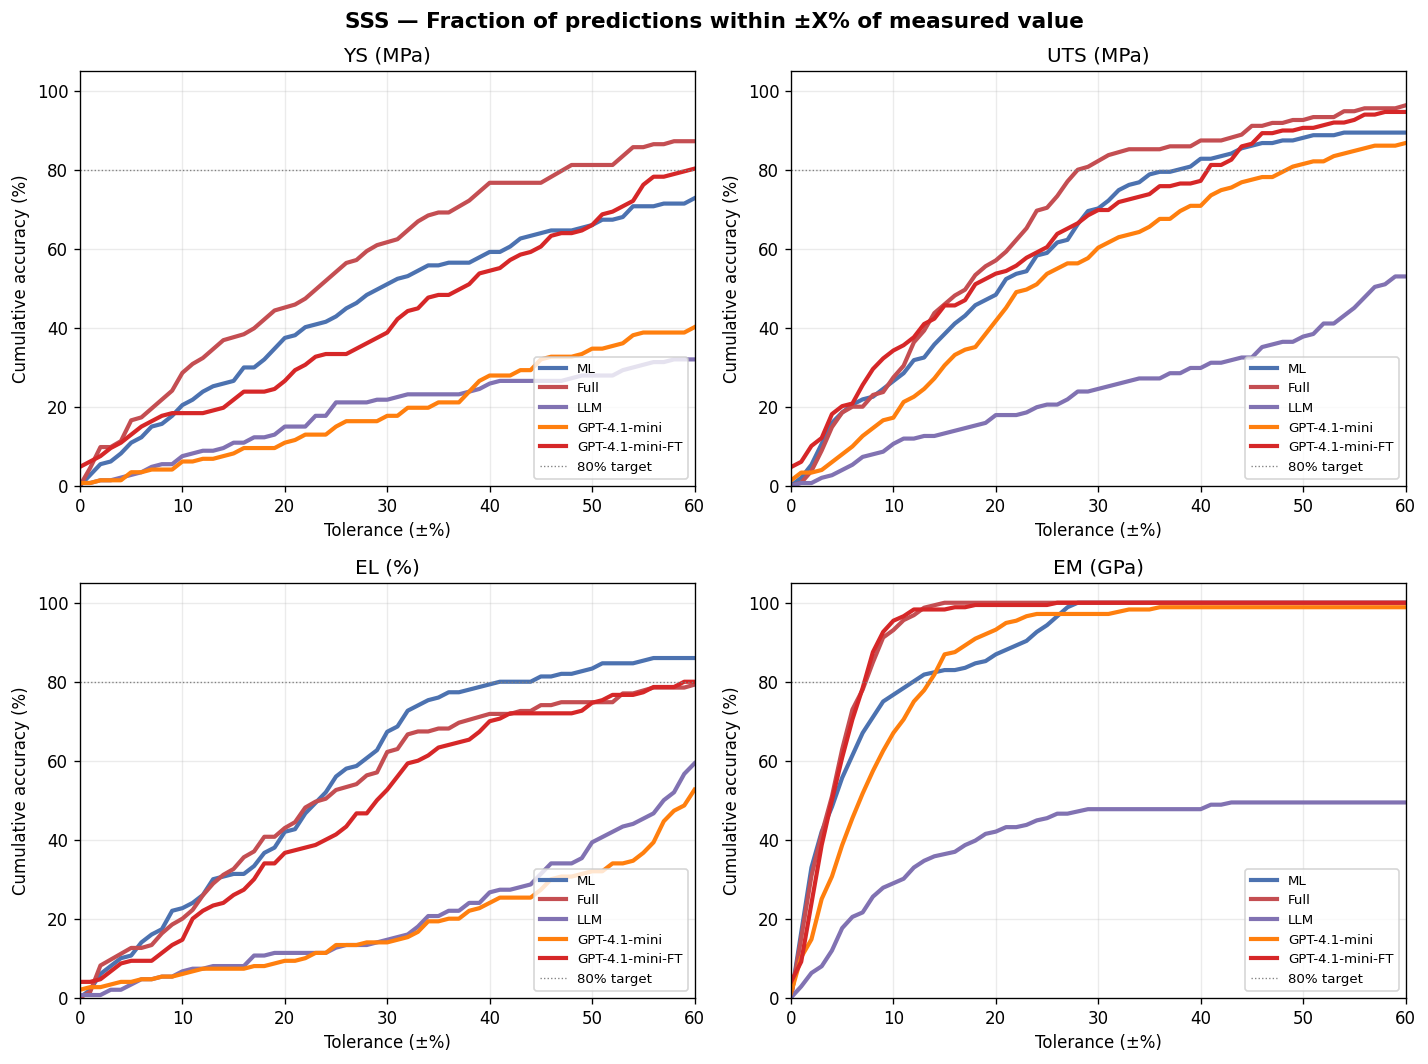

In [4]:
PLOT_METHODS = {'ML': ml, 'Full': full, 'LLM': llm,
                'GPT-4.1-mini': gpt, 'GPT-4.1-mini-FT': ft}
PLOT_COLORS  = {'ML': '#4C72B0', 'Full': '#C44E52', 'LLM': '#8172B2',
                'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}

tol = np.arange(0, 61, 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    for mn, df in PLOT_METHODS.items():
        acc = [pct_within(df, pc, ac, t) for t in tol]
        ax.plot(tol, acc, label=mn, color=PLOT_COLORS[mn], lw=2.5)
    ax.axhline(80, color='gray', ls=':', lw=0.8, label='80% target')
    ax.set(xlabel='Tolerance (\u00b1%)', ylabel='Cumulative accuracy (%)',
           title=lbl, xlim=(0, 60), ylim=(0, 105))
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('SSS \u2014 Fraction of predictions within \u00b1X% of measured value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 2 — Predicted vs Measured (Full System)

Parity plots for all four properties. Green band = ±10% tolerance; points within band shown in blue, outliers as red crosses.

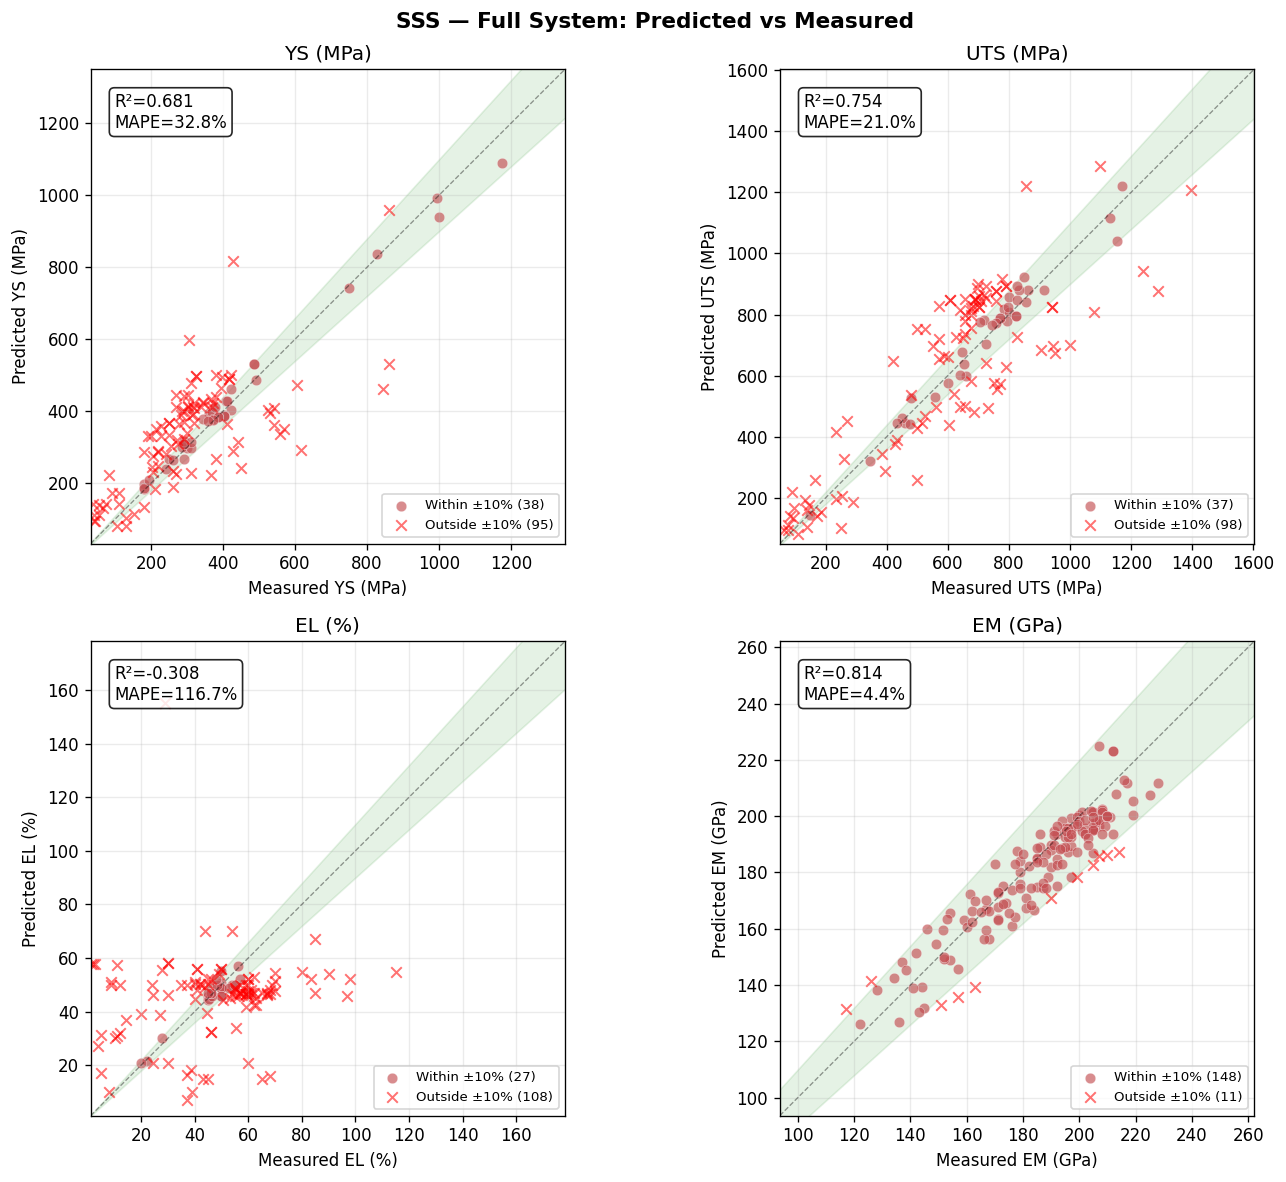

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    v = full[[pc, ac]].dropna()
    v = v[v[ac] != 0].copy()
    m = metrics(full, pc, ac)
    pe = ((v[pc] - v[ac]) / v[ac]).abs() * 100
    w = pe <= 10

    lo = min(v[ac].min(), v[pc].min()) * 0.8
    hi = max(v[ac].max(), v[pc].max()) * 1.15
    d = np.linspace(lo, hi, 100)
    ax.fill_between(d, d * 0.9, d * 1.1, alpha=0.10, color='green')
    ax.plot(d, d, 'k--', lw=0.8, alpha=0.4)

    ax.scatter(v.loc[w, ac], v.loc[w, pc], s=40, alpha=0.65,
               color=COLORS['Full'], edgecolors='white', lw=0.3,
               label=f'Within ±10% ({w.sum()})')
    ax.scatter(v.loc[~w, ac], v.loc[~w, pc], s=40, alpha=0.55,
               color='red', marker='x', lw=1.2,
               label=f'Outside ±10% ({(~w).sum()})')

    ax.text(0.05, 0.95, f"R²={m['r2']:.3f}\nMAPE={m['mape']:.1f}%",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set(xlabel=f'Measured {lbl}', ylabel=f'Predicted {lbl}',
           title=lbl, xlim=(lo, hi), ylim=(lo, hi), aspect='equal')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('SSS — Full System: Predicted vs Measured', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 3 — Case Studies: Temperature Sweeps

Two well-characterized SSS alloys with full RT-to-1100°C coverage, showing YS and UTS predictions against published datasheet values.

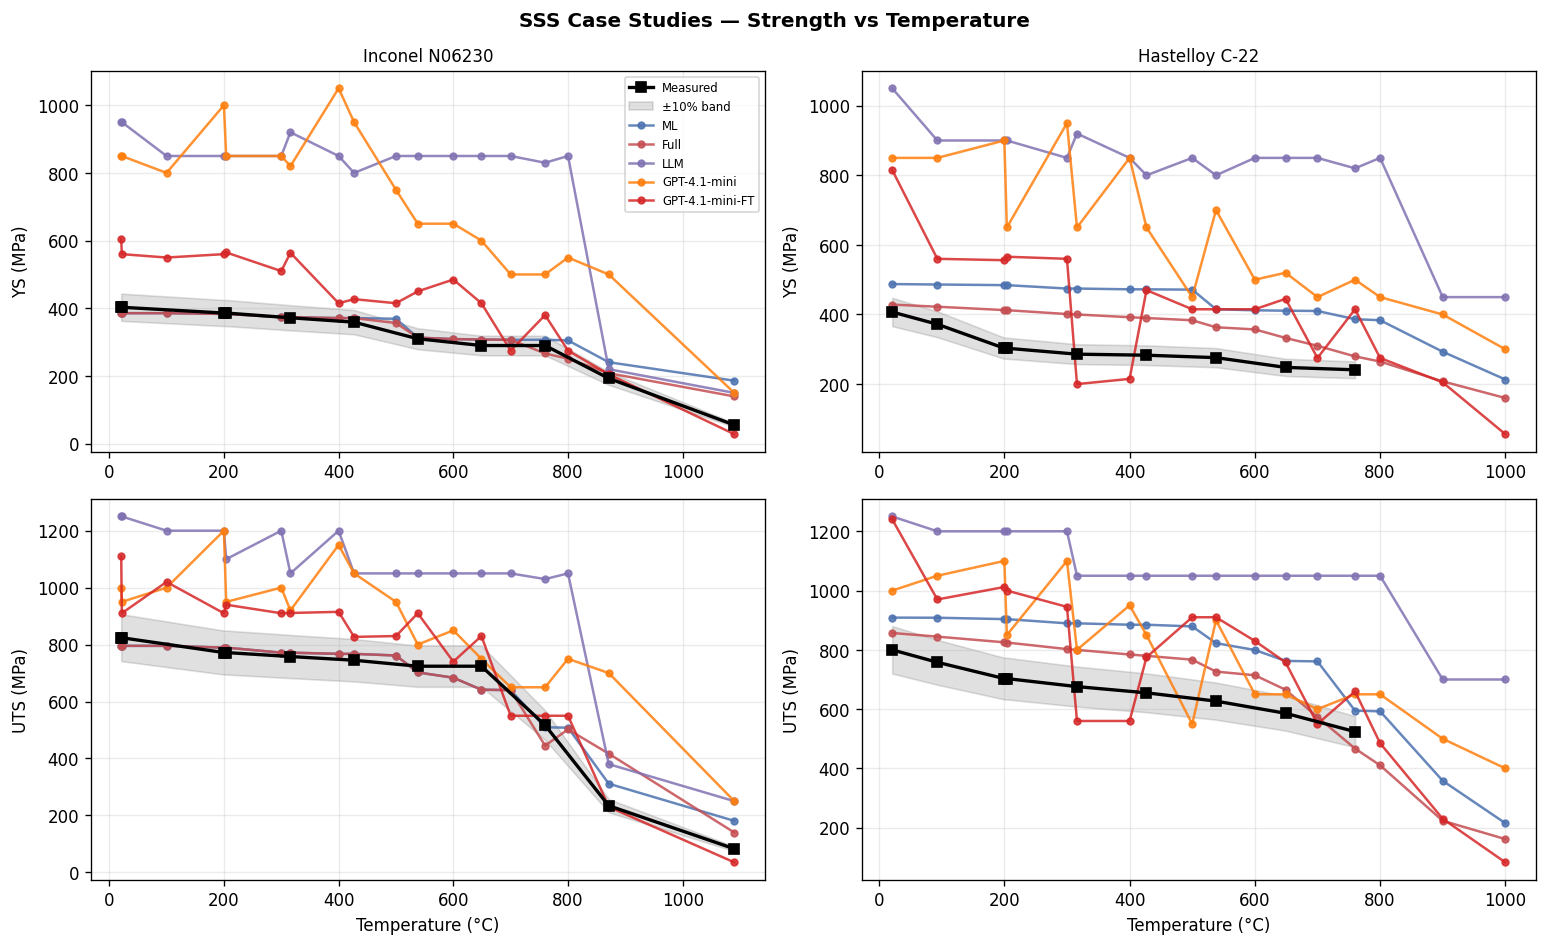

In [6]:
cases = [
    'Special Metals INCONEL\u00ae Alloy N06230 Ni-Cr-W-Mo Alloy',
    'Haynes Hastelloy\u00ae C-22\u00ae alloy',
]
short_names = ['Inconel N06230', 'Hastelloy C-22']
CASE_METHODS = ['ML', 'Full', 'LLM', 'GPT-4.1-mini', 'GPT-4.1-mini-FT']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('SSS Case Studies \u2014 Strength vs Temperature', fontsize=12, fontweight='bold')

for col, (alloy, sname) in enumerate(zip(cases, short_names)):
    for row, (pc, ac, ylabel) in enumerate([('pred_ys','actual_ys','YS (MPa)'),
                                             ('pred_uts','actual_uts','UTS (MPa)')]):
        ax = axes[row, col]
        ref = ml[ml['alloy']==alloy].sort_values('temperature')
        actual = ref[['temperature',ac]].dropna()
        if not actual.empty:
            ax.plot(actual['temperature'], actual[ac], 'ks-', ms=6, lw=2,
                    label='Measured', zorder=5)
            ax.fill_between(actual['temperature'], actual[ac]*0.9, actual[ac]*1.1,
                            alpha=0.12, color='black', label='\u00b110% band')

        for mn in CASE_METHODS:
            sub = METHODS[mn][METHODS[mn]['alloy']==alloy].sort_values('temperature')
            v = sub[['temperature',pc]].dropna()
            if not v.empty:
                ax.plot(v['temperature'], v[pc], 'o-', ms=4, lw=1.5,
                        color=COLORS[mn], label=mn, alpha=0.85)

        if row == 0: ax.set_title(sname, fontsize=10)
        ax.set(xlabel='Temperature (\u00b0C)' if row==1 else '', ylabel=ylabel)
        if col==0 and row==0: ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()